# V1 - HOG + SVM

**Obiettivo:** Classificare malattie di piante usando feature engineering classico (HOG) + SVM con kernel RBF.

**Pipeline:**
```
Immagine (256×256) → Grayscale → Resize (64×128) → HOG Features → SVM → Predizione
```

**Output:**
- `results/models/v1_hog_svm/svm_model.pkl`
- `results/metrics/v1_metrics.json`
- `results/plots/v1_confusion_matrix.png`

## 1. Setup & Imports

In [12]:
import os
import sys
import json
import pickle
import time
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

sns.set_style('whitegrid')
print('✅ Imports ok')
print(f'ROOT: {ROOT}')

✅ Imports ok
ROOT: /Users/marco/Documents/repos/ComputerVisionProject


## 2. Configurazione

In [13]:
# ── HOG ──────────────────────────────────────────────────────────────────────
HOG_WIN_SIZE    = (64, 128)   # larghezza × altezza
HOG_BLOCK_SIZE  = (16, 16)
HOG_BLOCK_STRIDE = (8, 8)
HOG_CELL_SIZE   = (8, 8)
HOG_NBINS       = 9

# ── SVM ──────────────────────────────────────────────────────────────────────
SVM_C           = 1.0
SVM_GAMMA       = 'scale'     # 1 / (n_features * X.var())
SVM_KERNEL      = 'rbf'

# ── Dataset ──────────────────────────────────────────────────────────────────
# RBF-SVM scala O(n²): per velocità sottocampioniamo il train.
# Imposta None per usare tutto il dataset (lento ~30+ min).
MAX_TRAIN_SAMPLES = None #10_000
RANDOM_SEED       = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = ROOT / 'data' / 'processed'
MODEL_DIR   = ROOT / 'results' / 'models' / 'v1_hog_svm'
METRICS_DIR = ROOT / 'results' / 'metrics'
PLOTS_DIR   = ROOT / 'results' / 'plots'

for d in [MODEL_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'MAX_TRAIN_SAMPLES : {MAX_TRAIN_SAMPLES}')
print(f'SVM kernel        : {SVM_KERNEL}  C={SVM_C}  gamma={SVM_GAMMA}')

MAX_TRAIN_SAMPLES : None
SVM kernel        : rbf  C=1.0  gamma=scale


## 3. Caricamento Dataset

In [14]:
def load_paths_labels(split_dir: Path):
    """Ritorna liste parallele (path, label_string) per uno split."""
    paths, labels = [], []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                paths.append(img_path)
                labels.append(class_dir.name)
    return paths, labels

train_paths, train_labels_str = load_paths_labels(DATA_DIR / 'train')
val_paths,   val_labels_str   = load_paths_labels(DATA_DIR / 'val')
test_paths,  test_labels_str  = load_paths_labels(DATA_DIR / 'test')

# Encoder classi → interi
le = LabelEncoder()
le.fit(train_labels_str)
classes = list(le.classes_)
NUM_CLASSES = len(classes)

train_labels = le.transform(train_labels_str)
val_labels   = le.transform(val_labels_str)
test_labels  = le.transform(test_labels_str)

print(f'Train : {len(train_paths):,} immagini')
print(f'Val   : {len(val_paths):,} immagini')
print(f'Test  : {len(test_paths):,} immagini')
print(f'Classi: {NUM_CLASSES}')

Train : 70,295 immagini
Val   : 8,777 immagini
Test  : 8,795 immagini
Classi: 38


## 4. HOG Feature Extraction

Ogni immagine viene convertita in grayscale, ridimensionata a `64×128` e processata dal `HOGDescriptor` di OpenCV.

**Dimensione feature vector:** `(block_x × block_y) × cells_per_block × nbins`
```
block_x = (64−16)/8 + 1 = 7
block_y = (128−16)/8 + 1 = 15
cells   = (16/8)² = 4
→ 7 × 15 × 4 × 9 = 3780 features/immagine
```

In [15]:
class HOGExtractor:
    def __init__(self):
        self.hog = cv2.HOGDescriptor(
            HOG_WIN_SIZE,
            HOG_BLOCK_SIZE,
            HOG_BLOCK_STRIDE,
            HOG_CELL_SIZE,
            HOG_NBINS
        )
        self.feature_dim = self.hog.getDescriptorSize()

    def extract(self, img_path: Path) -> np.ndarray | None:
        img = cv2.imread(str(img_path))
        if img is None:
            return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, HOG_WIN_SIZE)  # (w, h)
        features = self.hog.compute(resized)
        return features.flatten()

    def extract_batch(self, paths, desc='HOG'):
        features = np.zeros((len(paths), self.feature_dim), dtype=np.float32)
        valid_mask = np.ones(len(paths), dtype=bool)
        for i, p in enumerate(tqdm(paths, desc=desc)):
            f = self.extract(p)
            if f is not None:
                features[i] = f
            else:
                valid_mask[i] = False
        return features[valid_mask], valid_mask

extractor = HOGExtractor()
print(f'HOG feature dim: {extractor.feature_dim}')

HOG feature dim: 3780


In [16]:
# ── Subsample train (stratificato) ────────────────────────────────────────────
if MAX_TRAIN_SAMPLES and len(train_paths) > MAX_TRAIN_SAMPLES:
    sub_paths, sub_labels = resample(
        train_paths, train_labels,
        n_samples=MAX_TRAIN_SAMPLES,
        stratify=train_labels,
        random_state=RANDOM_SEED
    )
    print(f'Train sottocampionato: {len(sub_paths):,} immagini ({MAX_TRAIN_SAMPLES/len(train_paths)*100:.1f}%)')
else:
    sub_paths, sub_labels = train_paths, train_labels
    print(f'Usando tutto il train: {len(sub_paths):,} immagini')

# ── Estrai features ────────────────────────────────────────────────────────────
t0 = time.time()
X_train, mask_train = extractor.extract_batch(sub_paths, desc='HOG train')
y_train = sub_labels[mask_train]
print(f'Train features: {X_train.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
X_val, mask_val = extractor.extract_batch(val_paths, desc='HOG val')
y_val = val_labels[mask_val]
print(f'Val   features: {X_val.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
X_test, mask_test = extractor.extract_batch(test_paths, desc='HOG test')
y_test = test_labels[mask_test]
print(f'Test  features: {X_test.shape}  ({time.time()-t0:.1f}s)')

Usando tutto il train: 70,295 immagini


HOG train: 100%|██████████| 70295/70295 [00:24<00:00, 2840.27it/s]


Train features: (70295, 3780)  (24.9s)


HOG val: 100%|██████████| 8777/8777 [00:03<00:00, 2463.74it/s]


Val   features: (8777, 3780)  (3.6s)


HOG test: 100%|██████████| 8795/8795 [00:03<00:00, 2420.95it/s]


Test  features: (8795, 3780)  (3.6s)


## 5. Training SVM (RBF kernel)

In [17]:
print(f'Training SVM (kernel={SVM_KERNEL}, C={SVM_C}, gamma={SVM_GAMMA}) su {len(X_train):,} campioni...')

svm = SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA, random_state=RANDOM_SEED)

t0 = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - t0

print(f'✅ Training completato in {train_time:.1f}s ({train_time/60:.1f} min)')

# Salva modello
model_path = MODEL_DIR / 'svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': svm, 'label_encoder': le}, f)
print(f'💾 Modello salvato: {model_path.relative_to(ROOT)}')

Training SVM (kernel=rbf, C=1.0, gamma=scale) su 70,295 campioni...
✅ Training completato in 1511.1s (25.2 min)
💾 Modello salvato: results/models/v1_hog_svm/svm_model.pkl


## 6. Valutazione

In [18]:
def evaluate(model, X, y_true, split_name='Val'):
    t0 = time.time()
    y_pred = model.predict(X)
    inf_time = (time.time() - t0) / len(X) * 1000  # ms/immagine

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f'─── {split_name} ───────────────────────')
    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(f'  Inf. time : {inf_time:.3f} ms/img')

    return {
        'accuracy': float(acc), 'precision': float(prec),
        'recall': float(rec),   'f1': float(f1),
        'inference_ms_per_image': float(inf_time),
        'confusion_matrix': cm.tolist()
    }, y_pred

val_metrics, y_val_pred = evaluate(svm, X_val, y_val, 'Val')

─── Val ───────────────────────
  Accuracy  : 0.7272 (72.72%)
  Precision : 0.7295
  Recall    : 0.7272
  F1        : 0.7263
  Inf. time : 64.364 ms/img


In [19]:
test_metrics, y_test_pred = evaluate(svm, X_test, y_test, 'Test')

# Salva metriche
metrics = {
    'version': 'v1_hog_svm',
    'config': {
        'hog_win_size': HOG_WIN_SIZE,
        'hog_nbins': HOG_NBINS,
        'svm_kernel': SVM_KERNEL,
        'svm_C': SVM_C,
        'svm_gamma': SVM_GAMMA,
        'train_samples': int(len(X_train)),
        'train_time_s': float(train_time)
    },
    'val':  {k: v for k, v in val_metrics.items()  if k != 'confusion_matrix'},
    'test': {k: v for k, v in test_metrics.items() if k != 'confusion_matrix'},
    'confusion_matrix_val':  val_metrics['confusion_matrix'],
    'confusion_matrix_test': test_metrics['confusion_matrix']
}

metrics_path = METRICS_DIR / 'v1_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'💾 Metriche salvate: {metrics_path.relative_to(ROOT)}')

─── Test ───────────────────────
  Accuracy  : 0.7439 (74.39%)
  Precision : 0.7462
  Recall    : 0.7439
  F1        : 0.7426
  Inf. time : 64.551 ms/img
💾 Metriche salvate: results/metrics/v1_metrics.json


## 7. Visualizzazioni

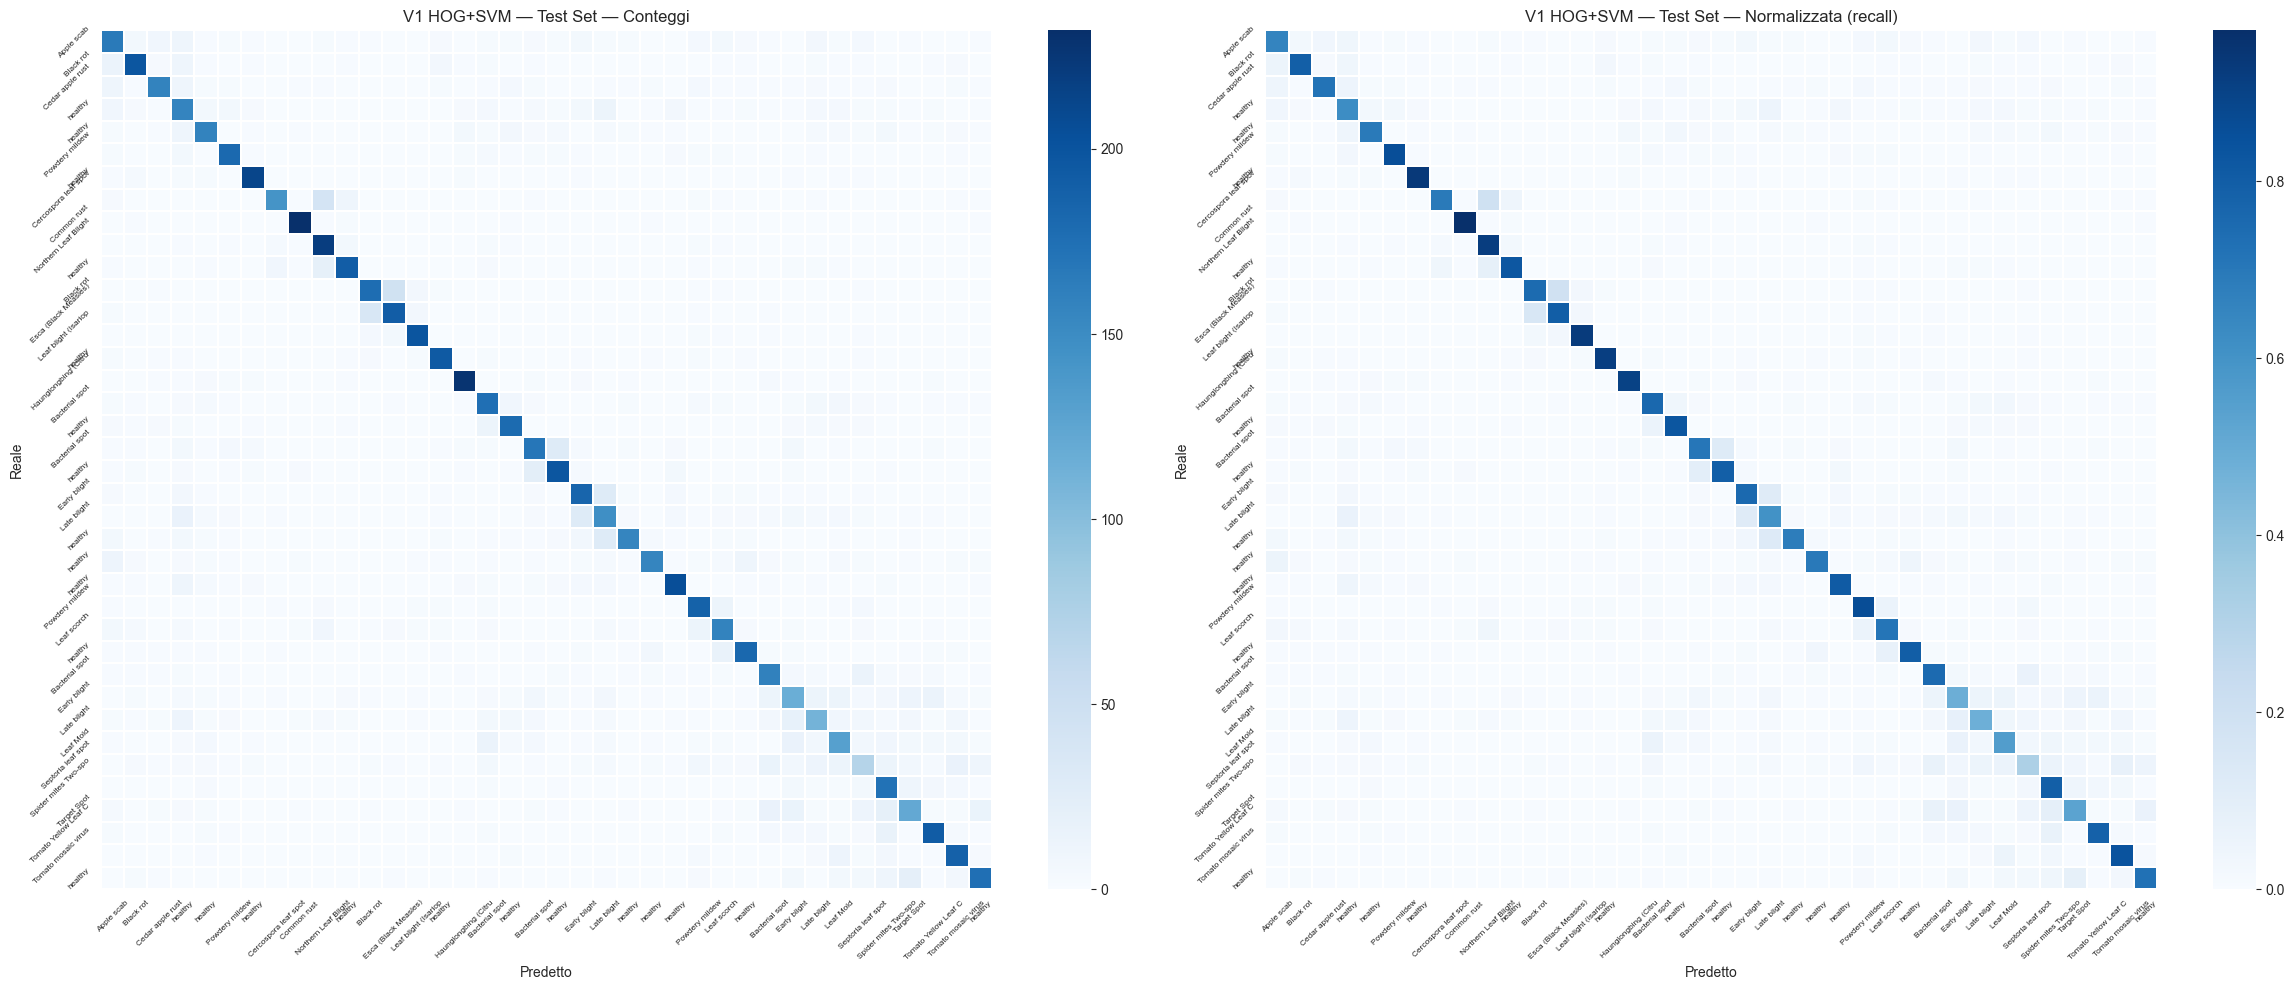

💾 Plot salvato: results/plots/v1_confusion_matrix.png


In [20]:
def plot_confusion_matrix(cm, class_names, title, save_path):
    # Normalizza per riga (recall per classe)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    for ax, data, fmt, subtitle in [
        (axes[0], cm,      'd',    'Conteggi'),
        (axes[1], cm_norm, '.2f',  'Normalizzata (recall)')
    ]:
        sns.heatmap(
            data, ax=ax, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot=(cm.shape[0] <= 15), fmt=fmt, linewidths=0.3
        )
        ax.set_title(f'{title} — {subtitle}', fontsize=12)
        ax.set_xlabel('Predetto', fontsize=10)
        ax.set_ylabel('Reale', fontsize=10)
        ax.tick_params(axis='both', labelsize=6, rotation=45)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Plot salvato: {Path(save_path).relative_to(ROOT)}')

short_names = [c.split('___')[1].replace('_', ' ')[:20] if '___' in c else c[:20] for c in classes]

plot_confusion_matrix(
    np.array(test_metrics['confusion_matrix']),
    short_names,
    title='V1 HOG+SVM — Test Set',
    save_path=PLOTS_DIR / 'v1_confusion_matrix.png'
)

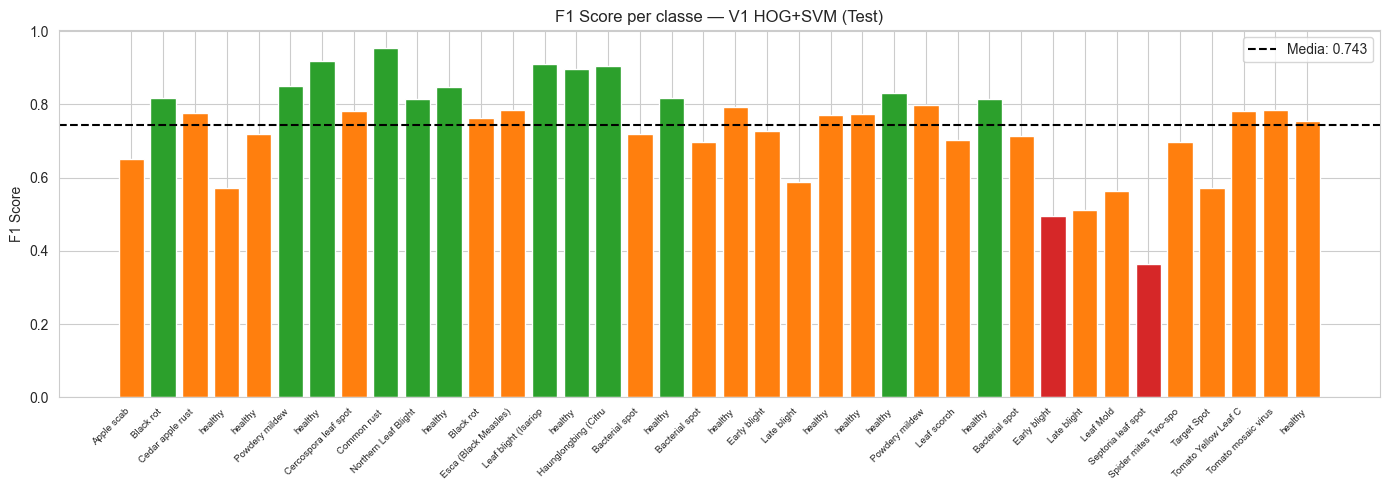


Classi con F1 più basso:
  Tomato___Septoria_leaf_spot                         F1=0.363
  Tomato___Early_blight                               F1=0.496
  Tomato___Late_blight                                F1=0.513
  Tomato___Leaf_Mold                                  F1=0.565
  Apple___healthy                                     F1=0.571


In [21]:
# Per-class F1 — utile per identificare classi difficili
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#d62728' if v < 0.5 else '#2ca02c' if v >= 0.8 else '#ff7f0e' for v in f1_per_class]
bars = ax.bar(range(NUM_CLASSES), f1_per_class, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per classe — V1 HOG+SVM (Test)')
ax.axhline(y=np.mean(f1_per_class), color='black', linestyle='--', label=f'Media: {np.mean(f1_per_class):.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'v1_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Classi peggiori
worst_idx = np.argsort(f1_per_class)[:5]
print('\nClassi con F1 più basso:')
for i in worst_idx:
    print(f'  {classes[i]:<50s}  F1={f1_per_class[i]:.3f}')

In [22]:
print('=' * 55)
print('  V1 HOG + SVM — Riepilogo Finale')
print('=' * 55)
print(f'  Campioni train usati : {len(X_train):,} / {len(train_paths):,}')
print(f'  Feature dim (HOG)    : {extractor.feature_dim}')
print(f'  Training time        : {train_time:.1f}s')
print()
for split, m in [('Val ', val_metrics), ('Test', test_metrics)]:
    print(f'  [{split}] Acc={m["accuracy"]:.4f}  P={m["precision"]:.4f}  R={m["recall"]:.4f}  F1={m["f1"]:.4f}')
print()
print(f'  Modello  : results/models/v1_hog_svm/svm_model.pkl')
print(f'  Metriche : results/metrics/v1_metrics.json')
print('=' * 55)
print('  ➡️  Prosegui con: 02_v2_custom_cnn.ipynb')

  V1 HOG + SVM — Riepilogo Finale
  Campioni train usati : 70,295 / 70,295
  Feature dim (HOG)    : 3780
  Training time        : 1511.1s

  [Val ] Acc=0.7272  P=0.7295  R=0.7272  F1=0.7263
  [Test] Acc=0.7439  P=0.7462  R=0.7439  F1=0.7426

  Modello  : results/models/v1_hog_svm/svm_model.pkl
  Metriche : results/metrics/v1_metrics.json
  ➡️  Prosegui con: 02_v2_custom_cnn.ipynb


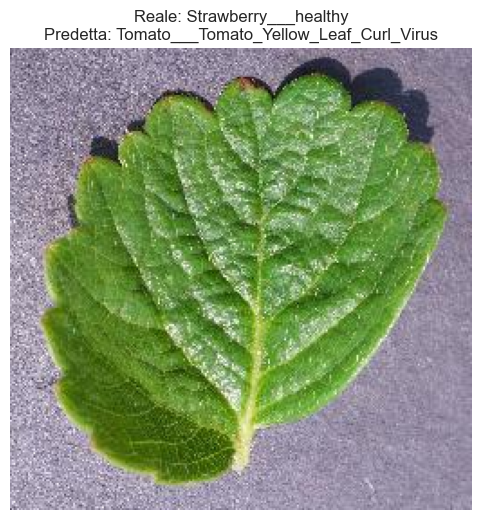

Immagine: /Users/marco/Documents/repos/ComputerVisionProject/data/processed/test/Strawberry___healthy/d94430d8-1f02-41c5-97b0-2fefd03ae088___RS_HL 4871.JPG
Classe reale : Strawberry___healthy
Classe predetta: Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [189]:
# Scegli un'immagine casuale dal set di test
t = len(test_paths)
if t == 0:
    raise ValueError('Il test set è vuoto, non ci sono immagini da visualizzare.')

sample_idx = np.random.randint(t)
sample_path = test_paths[sample_idx]
true_class = le.inverse_transform([test_labels[sample_idx]])[0]

feature = extractor.extract(sample_path).reshape(1, -1)
pred_idx = svm.predict(feature)[0]
pred_class = le.inverse_transform([pred_idx])[0]

img = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Reale: {true_class}\nPredetta: {pred_class}", fontsize=12)
plt.axis('off')
plt.show()

print(f"Immagine: {sample_path}")
print(f"Classe reale : {true_class}")
print(f"Classe predetta: {pred_class}")